In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras
from sklearn.utils import shuffle
from skimage.transform import resize
from sklearn.metrics import confusion_matrix
import glob

In [2]:
pip install scikit-image

  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   ---------------------------------------- 0.1/11.9 MB 1.9 MB/s eta 0:00:07
   - -------------------------------------- 0.6/11.9 MB 5.8 MB/s eta 0:00:02
   ---- ----------------------------------- 1.2/11.9 MB 9.8 MB/s eta 0:00:02
   ---- ----------------------------------- 1.5/11.9 MB 8.5 MB/s eta 0:00:02
   ------- -------------------------------- 2.3/11.9 MB 10.6 MB/s eta 0:00:01
   ----------- ---------------------------- 3.4/11.9 MB 11.9 MB/s eta 0:00:01
   -------------- ------------------------- 4.3/11.9 MB 13.6 MB/s eta 0:00:01
   ----------------- ---------------------- 5.3/11.9 MB 14.1 MB/s eta 0:00:01
   ------------------- -------------------- 5.9/11.9 MB 14.4 MB/s eta 0:00:01
   --------------------- ------------------ 6.5/11.9 MB 13.8 MB/s eta 0:00:01
   ----------------------- ---------------- 7.0/11.9 MB 13.9 MB/s eta 0:00:01
   --------


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
cats = glob.glob('cat and dog/training_set/cats/*.jpg')
dogs = glob.glob('cat and dog/training_set/dogs/*.jpg')

In [5]:
cats_test = glob.glob('cat and dog/test_set/cats/*.jpg')
dogs_test = glob.glob('cat and dog/test_set/dogs/*.jpg')

In [9]:
print("Number of images in Training are, Cats:",len(cats),",Dogs:",len(dogs))
print("Number of images in testing are, Dogs:",len(cats_test),",dogs:",len(dogs_test))

Number of images in Training are, Cats: 108 ,Dogs: 107
Number of images in testing are, Dogs: 38 ,dogs: 56


In [10]:
print("Datatype of Training set, Cats:", type(cats),",Dogs:",type(dogs))
print("Datatype of training set, Cats:", type(cats_test),",Dogs:",type(dogs_test))

Datatype of Training set, Cats: <class 'list'> ,Dogs: <class 'list'>
Datatype of training set, Cats: <class 'list'> ,Dogs: <class 'list'>


In [11]:
image = []
label = []

for i in cats:
    img = plt.imread(i)
    image.append(img)
    label.append(0)


for i in dogs:
    img = plt.imread(i)
    image.append(img)
    label.append(1)

In [14]:
image_test = []
label_test = []

for i in cats:
    img = plt.imread(i)
    image_test.append(img)
    label_test.append(0)
for i in dogs:
    img = plt.imread(i)
    image_test.append(img)
    label_test.append(1)
    

In [15]:
image, label = shuffle(image,label, random_state = 100)

In [16]:
image_test, label_test = shuffle(image_test,label_test, random_state = 100)

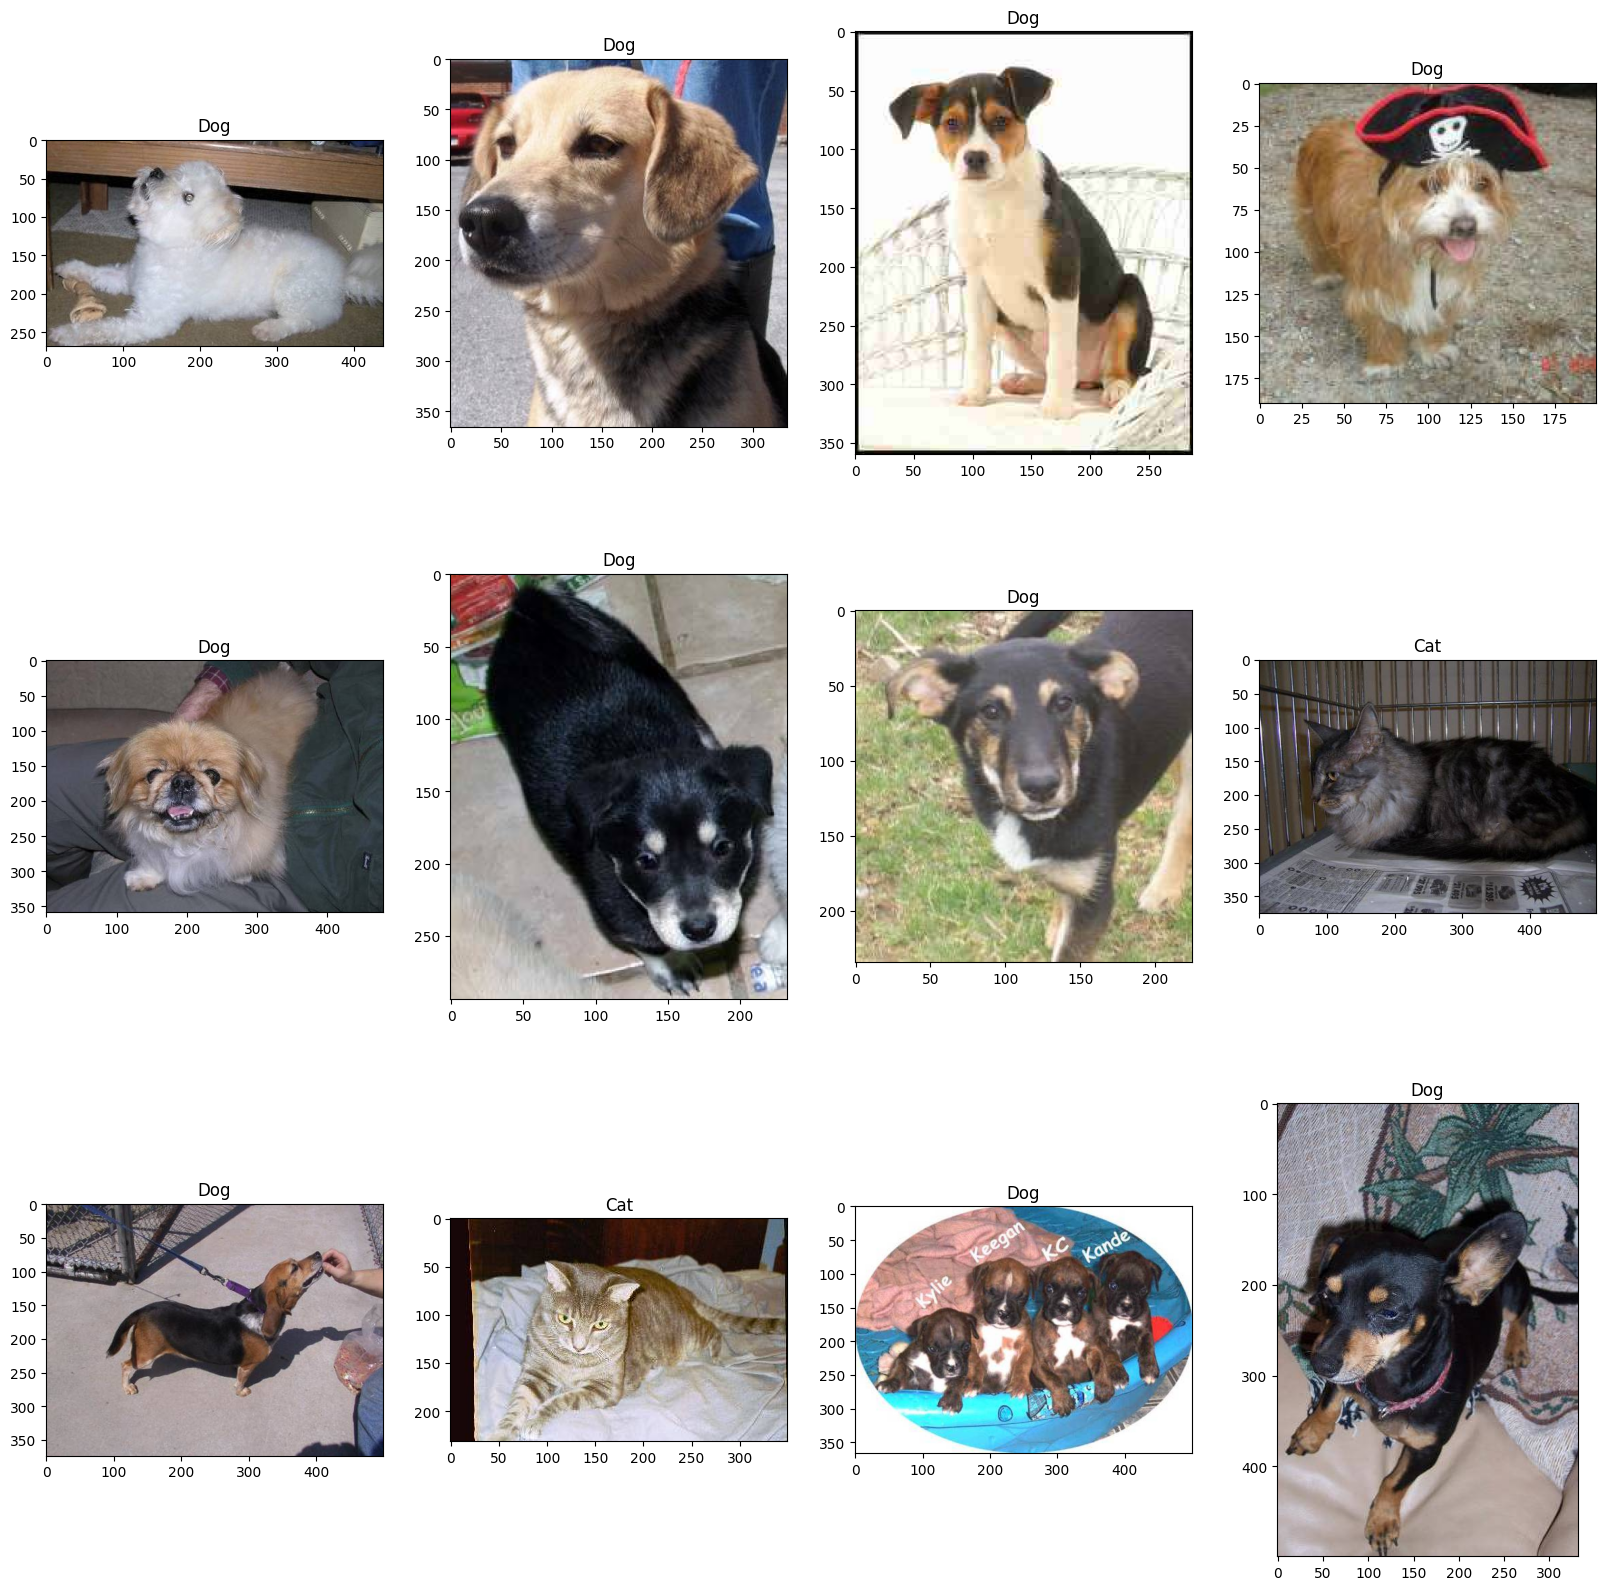

In [17]:
plt.figure(figsize = (20,20))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(image[i])
    if label[i] == 1:
        plt.title('Dog')
    else:
        plt.title('Cat')

In [18]:
X_train = []

for i in image:
    X_train.append(resize(i,(64,64,3)))
    
X_train = np.array(X_train)

In [19]:
X_test = []

for i in image:
    X_test.append(resize(i,(64,64,3)))

X_test = np.array(X_test)

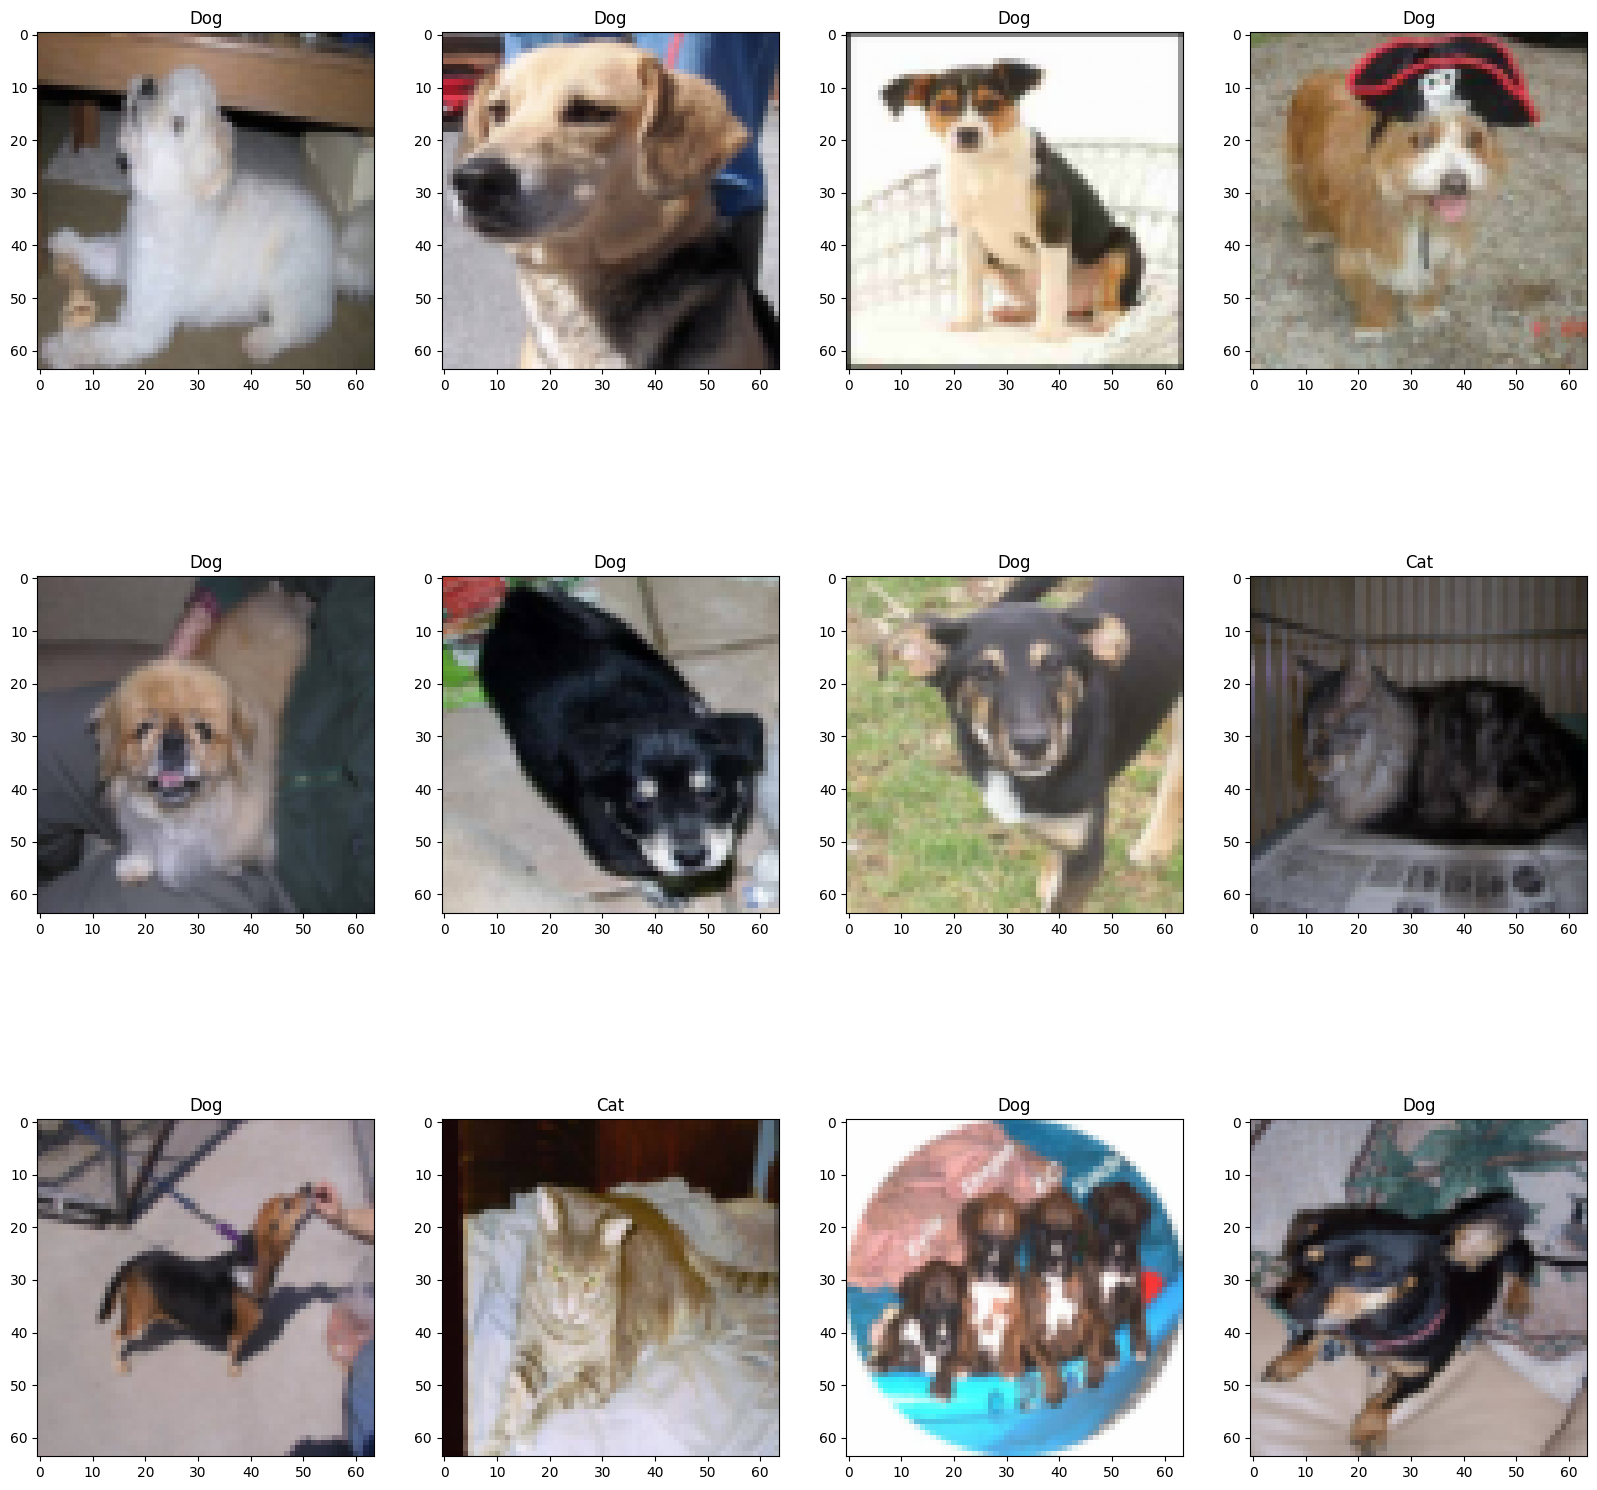

In [21]:
plt.figure(figsize = (20,20))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X_train[i])
    if label[i] == 1:
        plt.title('Dog')
    else:
        plt.title('Cat')

In [22]:
print(type(X_train))
print(type(label))

<class 'numpy.ndarray'>
<class 'list'>


In [23]:
y_train = np.array(label)
y_test = np.array(label_test)

In [24]:
print(type(y_train))
print(type(y_test))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [25]:
X_train.shape

(215, 64, 64, 3)

In [26]:
y_train.shape

(215,)

In [29]:
model = RandomForestClassifier()

In [28]:
from sklearn.ensemble import RandomForestClassifier

In [30]:
model = keras.models.Sequential([
    keras.layers.Conv2D(16, (3,3), activation = 'relu', input_shape = (64, 64, 3)),
    keras.layers.MaxPool2D(2,2),
    
    keras.layers.Conv2D(32,(3,3), activation = 'relu'),
    keras.layers.MaxPool2D(2,2),
    
    keras.layers.Flatten(),
    
    keras.layers.Dense(64, activation = 'relu'),
    keras.layers.Dense(1, activation = 'sigmoid')
])

C:\Users\Rahul\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [32]:
model.compile(optimizer = 'adam',
             loss = 'binary_crossentropy',
             metrics = ['accuracy'])

In [33]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 16)          │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 6272)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │         401,472 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 406,625 (1.55 MB)

 Trainable params: 406,625 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [34]:
model.fit(X_train,y_train, epochs=30, steps_per_epoch=3, validation_split=0.1)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 216ms/step - accuracy: 0.5337 - loss: 0.7172 - val_accuracy: 0.6818 - val_loss: 0.6616
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.4819 - loss: 0.7168 - val_accuracy: 0.5909 - val_loss: 0.6883
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.6114 - loss: 0.6749 - val_accuracy: 0.3182 - val_loss: 0.7736
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.5181 - loss: 0.6762 - val_accuracy: 0.3182 - val_loss: 0.7408
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 0.5285 - loss: 0.6608 - val_accuracy: 0.3182 - val_loss: 0.7096
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.6218 - loss: 0.6456 - val_accuracy: 0.3636 - val_loss: 0.6928
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - accuracy: 0.6736 - loss: 0.6251 - val_accuracy: 0.5909 - val_loss: 0.6771
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.7098 - loss: 0.5961 - val_accuracy: 0.6364 - val_loss: 0.6695

In [35]:
model.evaluate(X_train, y_train)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9209 - loss: 0.2650 


[0.2650335729122162, 0.9209302067756653]

In [36]:
prediction = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


In [42]:
prediction

array([[0.7317353 ],
       [0.9384513 ],
       [0.94879943],
       [0.94369024],
       [0.7520999 ],
       [0.87631834],
       [0.91365385],
       [0.1824584 ],
       [0.9092217 ],
       [0.03858693],
       [0.98654026],
       [0.7769109 ],
       [0.07969629],
       [0.9299886 ],
       [0.7804267 ],
       [0.7704751 ],
       [0.92502135],
       [0.9716445 ],
       [0.0041716 ],
       [0.901471  ],
       [0.966126  ],
       [0.2628363 ],
       [0.05968018],
       [0.8374205 ],
       [0.23132367],
       [0.44833162],
       [0.07343666],
       [0.7277426 ],
       [0.01676353],
       [0.29688817],
       [0.8313067 ],
       [0.23274279],
       [0.04947592],
       [0.07512946],
       [0.9592767 ],
       [0.97428346],
       [0.05582819],
       [0.49312505],
       [0.09782325],
       [0.9723414 ],
       [0.56115687],
       [0.9659393 ],
       [0.97429985],
       [0.957498  ],
       [0.2969268 ],
       [0.59595084],
       [0.07136999],
       [0.071

In [39]:
pred = []

for i in prediction:
    if i > 0.5:
        pred.append(0)
    else:
        pred.append(1)

In [40]:
pred

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 1,
 1,
 0]

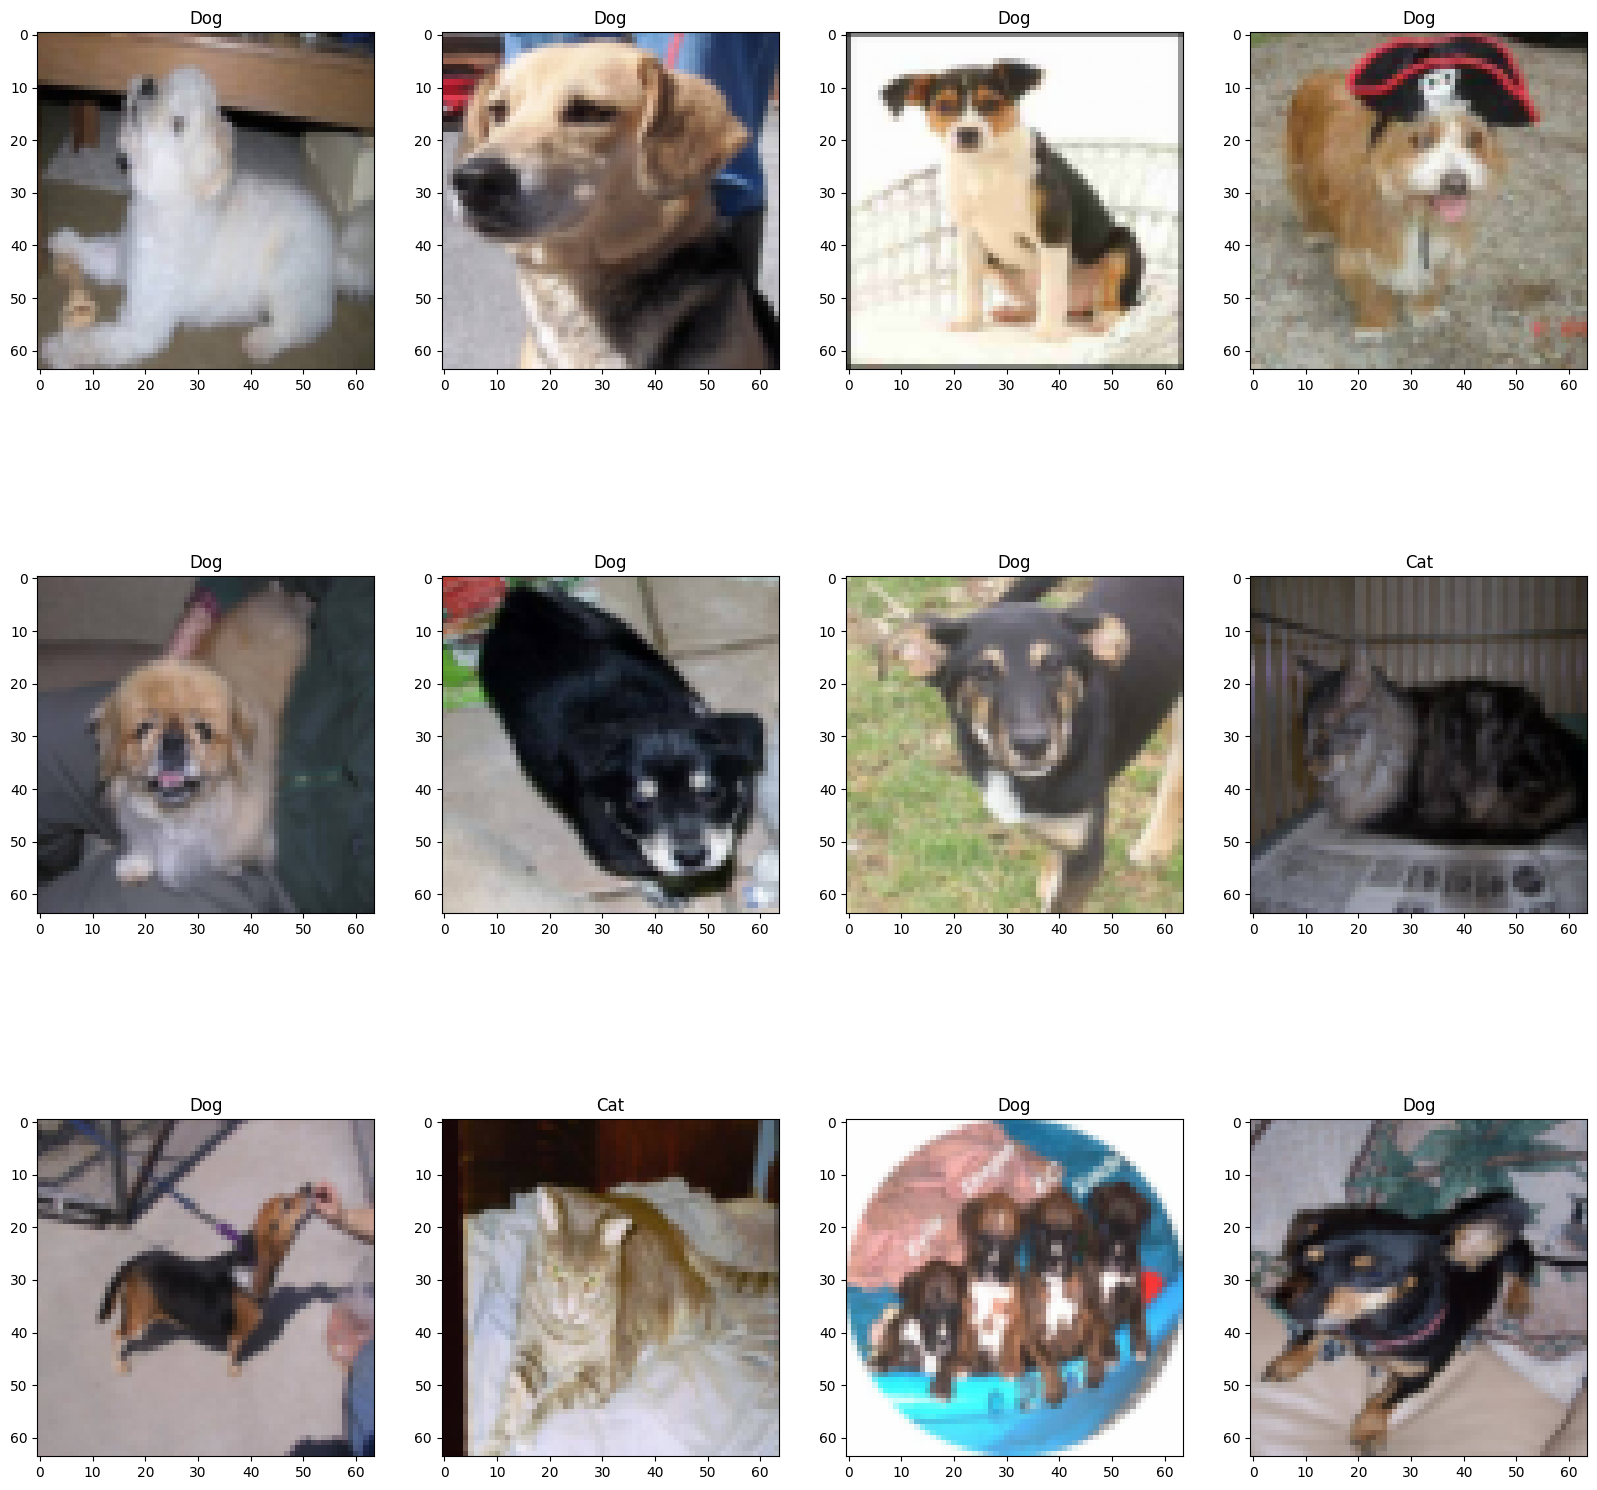

In [43]:
plt.figure(figsize = (20,20))
for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X_test[i])
    if pred[i] == 1:
        plt.title('Cat')
    else:
        plt.title('Dog')

In [47]:
model.evaluate(X_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9209 - loss: 0.2650


[0.2650335729122162, 0.9209302067756653]

In [49]:
prediction = model.predict(X_test)

pred = []
for i in prediction:
    if i > 0.5:
        pred.append(1)
    else:
        pred.append(0)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [50]:
model.fit(X_train, y_train,
          epochs=20,
          validation_data=(X_test, y_test))

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - accuracy: 0.9209 - loss: 0.2619 - val_accuracy: 0.9442 - val_loss: 0.2225
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9209 - loss: 0.2579 - val_accuracy: 0.9628 - val_loss: 0.1845
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.9488 - loss: 0.2128 - val_accuracy: 0.9721 - val_loss: 0.1702
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.9581 - loss: 0.1757 - val_accuracy: 0.9349 - val_loss: 0.1958
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.9488 - loss: 0.1596 - val_accuracy: 0.9721 - val_loss: 0.1473
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step - accuracy: 0.9814 - loss: 0.1278 - val_accuracy: 1.0000 - val_loss: 0.0985
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.9953 - loss: 0.0950 - val_accuracy: 1.0000 - val_loss: 0.0801
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 1.0000 - loss: 0.0761 - val_accuracy: 1.0000 - val_loss: 0.0655


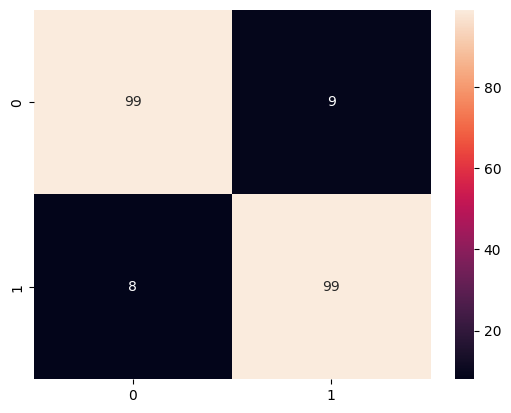

In [51]:
sns.heatmap(confusion_matrix(y_test,pred), annot = True)
plt.show()